# RECOMMENDATION MODEL

Nesse notebook vou desenvolver o sistema de recomendacao baseado em similaridade usando o algoritmo `Nearest Neighbors`

## IMPORTAÇÕES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler 
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

## CARREGAMENTO

In [2]:
df_spotify = pd.read_csv(r'../data/dataset.csv')

In [3]:
display(df_spotify.head(n=3))

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,...,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,...,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,...,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


## LIMPEZA

In [4]:
df_spotify = df_spotify.dropna()
df_spotify = df_spotify.drop(columns=['Unnamed: 0'])

display(df_spotify.head(n=3))
display(df_spotify.isnull().sum())

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

## FEATURES

In [5]:
features = ["danceability",
            "energy",
            "loudness",
            "speechiness",
            "acousticness",
            "instrumentalness",
            "liveness",
            "valence",
            "tempo"]

In [6]:
display(df_spotify[features])

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.7150,87.917
1,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.2670,77.489
2,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.1200,76.332
3,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.1430,181.740
4,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.1670,119.949
...,...,...,...,...,...,...,...,...,...
113995,0.172,0.2350,-16.393,0.0422,0.6400,0.928000,0.0863,0.0339,125.995
113996,0.174,0.1170,-18.318,0.0401,0.9940,0.976000,0.1050,0.0350,85.239
113997,0.629,0.3290,-10.895,0.0420,0.8670,0.000000,0.0839,0.7430,132.378
113998,0.587,0.5060,-10.889,0.0297,0.3810,0.000000,0.2700,0.4130,135.960


## ESCALONAMENTO 

In [7]:
scaler = StandardScaler()

df_modelagem = df_spotify[features]

df_modelagem_escalado = scaler.fit_transform(df_modelagem)

## TREINAMENTO DO MODELO

In [8]:
modelo_NN = NearestNeighbors(n_neighbors=6,
                             metric="euclidean")

modelo_NN.fit(df_modelagem_escalado)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


## TESTE DO MODELO

## BUSCA DE VIZINHOS

Nessa etapa selecionei a musica "believer" como referencia e utilizei o modelo treinado para identificar as faixas mais semelhantes com base nas características musicais utilizadas durante o treinamento.

In [9]:
indice = df_spotify[df_spotify['track_name'].str.lower() == 'believer'].index[0]

musica = df_modelagem_escalado[indice]

musica = musica.reshape(1, -1)

In [10]:
distancias, indices = modelo_NN.kneighbors(musica)


resultado = df_spotify.iloc[indices[0]][
    ["track_name", "artists", "track_genre"]
]

resultado

,track_name,artists,track_genre
27169,Believer,Friction,drum-and-bass
27631,Dying Light,Metrik;ShockOne,drum-and-bass
27705,Thinkin About - T & Sugah Remix,ShockOne;Lee Mvtthews;T & Sugah,drum-and-bass
5618,ninelie,Aimer;Chelly,anime
63501,ninelie,Aimer;Chelly,j-rock
85909,Rav,The Minds Of 99,punk-rock


## AVALIAÇÃO DO MODELO

Nessa etapa avalio se as recomendacoes feitas pelo algoritmo apresentam características semelhantes a musica de teste.

In [11]:
resultado_indices = indices[0]

comparacao = df_spotify.iloc[resultado_indices][["track_name",
                                                 "track_genre",
                                                 "danceability",
                                                 "energy",
                                                 "loudness",
                                                 "speechiness",
                                                 "acousticness",
                                                 "instrumentalness",
                                                 "liveness",
                                                 "valence",
                                                 "tempo"]]

comparacao

,track_name,track_genre,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
27169,Believer,drum-and-bass,0.490,0.894,-4.474,0.0431,0.012900,0.002760,0.0974,0.189,173.949
27631,Dying Light,drum-and-bass,0.492,0.867,-4.423,0.0377,0.000966,0.064400,0.1100,0.249,174.032
27705,Thinkin About - T & Sugah Remix,drum-and-bass,0.522,0.861,-3.469,0.0473,0.043600,0.000006,0.1130,0.213,173.958
5618,ninelie,anime,0.462,0.850,-5.558,0.0453,0.025600,0.000019,0.0756,0.206,172.063
63501,ninelie,j-rock,0.462,0.850,-5.558,0.0453,0.025600,0.000019,0.0756,0.206,172.063
85909,Rav,punk-rock,0.489,0.833,-5.122,0.0498,0.016800,0.000445,0.0943,0.201,166.856


## VISUALIZAÇÃO DAS RECOMENDAÇÕES COM PCA

As musicas do dataset são representadas por 9 características musicais, o que dificulta um pouco a visualização.
Para facilitar, utilizei a técnica PCA (Principal Component Analysis), reduzindo os dados para 2 dimensões. 

In [12]:
pca = PCA(n_components=2)

componentes = pca.fit_transform(df_modelagem_escalado)

In [13]:
df_pca = pd.DataFrame(componentes,
                      columns=["PCA1","PCA2"])

display(df_pca.head())

,PCA1,PCA2
0,0.639565,1.081869
1,-3.331079,1.009659
2,-1.387508,-0.206647
3,-3.379290,-0.651670
4,-0.988600,0.255113


In [14]:
print(pca.explained_variance_ratio_)
print(f'{pca.explained_variance_ratio_.sum():.2f}')

[0.31928144 0.15850939]
0.48


### VARIÂNCIA EXPLICADA

As duas PCA preservaram 48% da variabilidade original dos dados.
Existiu perda de informacao durante a reducão de dimensão porem esse resultado ja é suficiente para fins de visualizacao, permitindo observar padrões de proximidade entre as musicas em um espaço de 2 dimensões.

## VISUALIZAÇÃO COM SCATTERPLOT

In [15]:
df_pca['indice_original'] = df_spotify.index

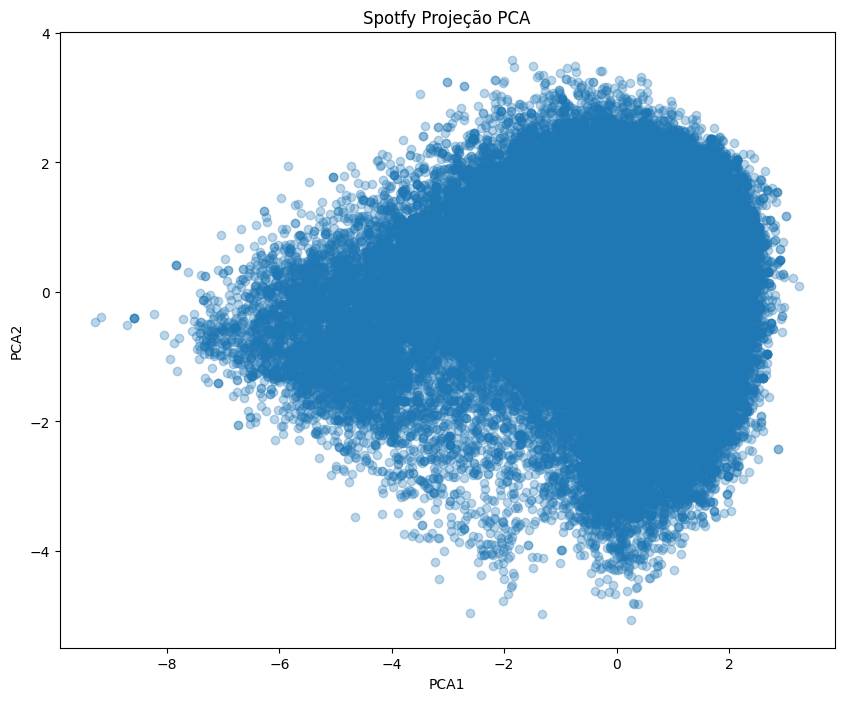

In [16]:
plt.figure(figsize=(10,8))

plt.scatter(x=df_pca["PCA1"],
            y=df_pca["PCA2"],
            alpha=0.3)


plt.title("Spotfy Projeção PCA")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

### VISUALIZAÇÃO DOS VIZINHOS PROXIMOS COM SCATTERPLOT

Nessa etapa destaquei a musica believer que usei anteriormente para o teste, e suas recomendacões na projeção PCA. Como o Nearest Neighbors usa distância para similaridade, é esperado que as musicas recomendadas estejam proximas a musica original.

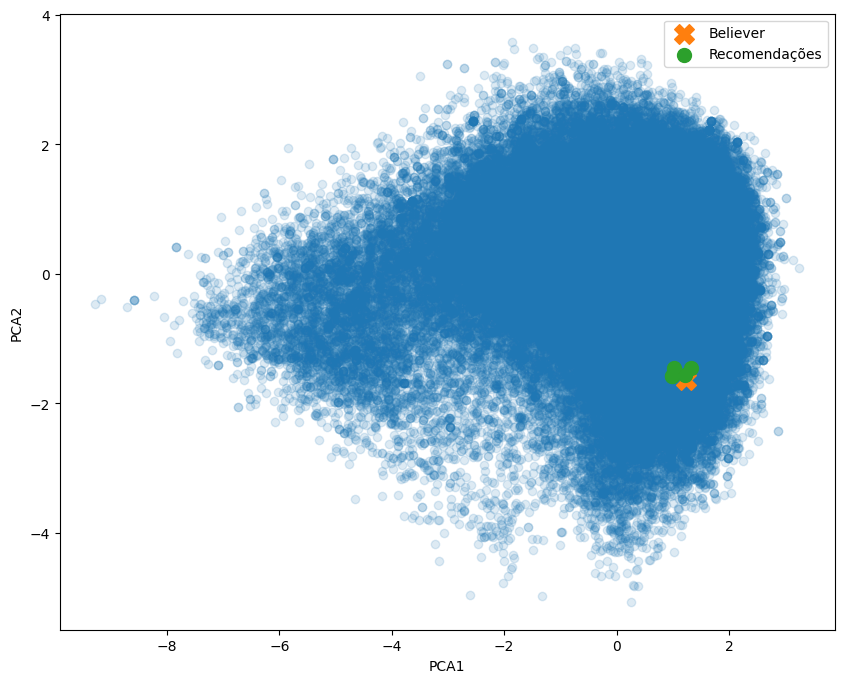

In [17]:
plt.figure(figsize=(10,8))

# SCATTER DE TODAS AS MUSICAS
plt.scatter(
            x=df_pca["PCA1"],
            y=df_pca["PCA2"],
            alpha=0.15)


# SCATTER DA MUSICA TESTE
plt.scatter(
            df_pca.loc[indice, "PCA1"],
            df_pca.loc[indice, "PCA2"],
            s=200,
            marker="X",
            label="Believer")

plt.scatter(
    df_pca.iloc[indices[0][1:]] ["PCA1"],
    df_pca.iloc[indices[0][1:]] ["PCA2"],
    s=100,
    label="Recomendações"
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend()

plt.show()

## INTERPRETAÇÃO DOS RESULTADOS

A análise das recomendações mostrou que as musicas sugeridas apresentam caracteristicas semelhantes com a musica teste (believer).

Além disso, a PCA demonstrou que as recomendações ocupam regiões bem próximas da musica teste, indicando que o algoritmo conseguiu identificar padrões de similaridade entre as faixas.

Esses resultados ajudam a evidenciar que o modelo de recomendações com Nearest Neighbors está funcionando! 

# IMPLEMENTAÇÃO DO SISTEMA DE RECOMENDAÇÃO

Nessa etapa criarei uma funçao para consultar o modelo treinado e retornar recomendações de músicas semelhantes.

In [25]:
def recommendation_song(song_name,
                        artist="NULL"):
    
    procurar_musica = df_spotify[df_spotify["track_name"].str.lower() == song_name.lower()]
    
    if procurar_musica.empty:
        print(f"A musica ({song_name}) não foi encontrada na base de dados utilizada neste projeto.")
    else:
        indice = procurar_musica.index[0]
        
        musica = df_modelagem_escalado[indice]
        
        musica = musica.reshape(1,-1) 
        
        distancias, indices = modelo_NN.kneighbors(musica)
        
        df_recommendation_music = df_spotify.iloc[indices[0]][
                                 ["track_name", "artists","album_name", "track_genre"]]
        
        
        return df_recommendation_music

# DEMONSTRAÇÃO DO SISTEMA

In [26]:
recommendation_song(song_name="believer")

,track_name,artists,album_name,track_genre
27169,Believer,Friction,Believer,drum-and-bass
27631,Dying Light,Metrik;ShockOne,Ex Machina,drum-and-bass
27705,Thinkin About - T & Sugah Remix,ShockOne;Lee Mvtthews;T & Sugah,Thinkin About (T & Sugah Remix),drum-and-bass
5618,ninelie,Aimer;Chelly,daydream,anime
63501,ninelie,Aimer;Chelly,daydream,j-rock
85909,Rav,The Minds Of 99,The Minds Of 99,punk-rock


In [27]:
recommendation_song(song_name="shape of you")

,track_name,artists,album_name,track_genre
45459,Shape Of You,Andrew Foy,Best Covers,guitar
76731,Les Indes Galantes - Air pour les esclaves afr...,Jean-Philippe Rameau;Jordi Savall;Le Concert D...,Rameau: L'Orchestre de Louis XV,opera
16096,"Brandenburg Concerto No. 3 in G, BWV 1048: 1. ...",Johann Sebastian Bach;Berliner Philharmoniker;...,Weihnachten Klassik 2022,classical
16040,"Brandenburg Concerto No. 3 in G, BWV 1048: 1. ...",Johann Sebastian Bach;Berliner Philharmoniker;...,Classical Christmas,classical
39093,"Brandenburg Concerto No. 3 in G, BWV 1048: 1. ...",Johann Sebastian Bach;Berliner Philharmoniker;...,Weihnachten Klassik 2022,german
16078,"Brandenburg Concerto No. 3 in G, BWV 1048: 1. ...",Johann Sebastian Bach;Berliner Philharmoniker;...,Classical Christmas 2022,classical


In [28]:
recommendation_song(song_name="counting stars")

,track_name,artists,album_name,track_genre
79000,I Ain't Worried,OneRepublic,I Ain’t Worried (Music From The Motion Picture...,piano
79007,I Ain't Worried,OneRepublic,TickTok Back To School 2022,piano
79006,I Ain't Worried,OneRepublic,HOT PARTY BACK TO SCHOOL 2022,piano
79005,I Ain't Worried,OneRepublic,Frühstücksmusik Herbst/Winter 2022/2023,piano
79004,I Ain't Worried,OneRepublic,TickTok Back To School 2022,piano
79003,I Ain't Worried,OneRepublic,Arbeitsmusik Herbst/Winter 2022/2023,piano


In [29]:
recommendation_song(song_name="radioactive")

,track_name,artists,album_name,track_genre
66792,Litt Sister Anthem,KD Da Kid,Litt Sister Anthem,kids
88642,Te Reto,Alexis y Fido;Yandel,Noche de Halloween Latino,reggae
68599,Te Reto,Alexis y Fido;Yandel,Noche de Halloween Latino,latino
89644,Te Reto,Alexis y Fido;Yandel,Noche de Halloween Latino,reggaeton
67893,Te Reto,Alexis y Fido;Yandel,Noche de Halloween Latino,latin
37650,Don't Like,Goldy;Karan Aujla,Don't Like,funk


## ANÁLISE DOS RESULTADOS

Realizei testes com diferentes musicas para ver a capacidade do sistema em identificar faixas semelhantes.
De forma geral, as recomendações apresentaram características próximas as músicas consultadas, indicando que o modelo conseguiu encontrar padrões utilizando as features selecionadas.